======== RESULTADOS DO TESTE QUI-QUADRADO ========
Valor de Qui-Quadrado: 0.6614
P-valor: 0.9560
Graus de Liberdade: 4

Decisão: Não rejeitamos H0: O nível de ensino NÃO está associado à região (Independência).



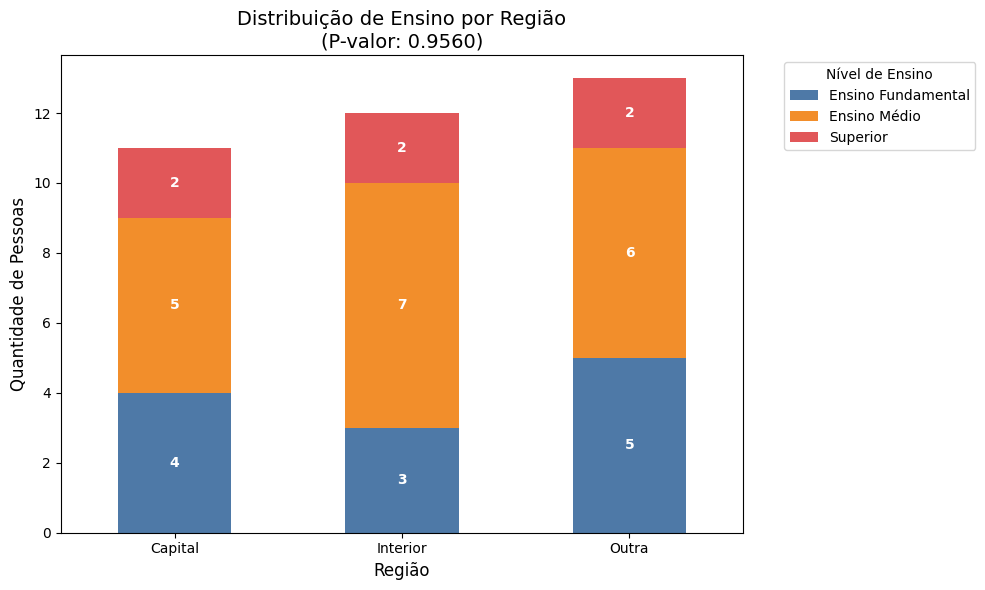

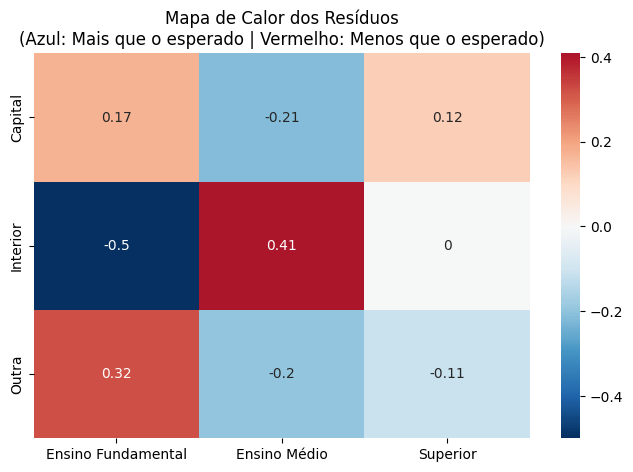

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# 1. Preparação dos dados da imagem
# Organizado em um dicionário para facilitar a plotagem e leitura
dados = {
    'Ensino Fundamental': [4, 3, 5],
    'Ensino Médio': [5, 7, 6],
    'Superior': [2, 2, 2]
}
regioes = ['Capital', 'Interior', 'Outra']
df = pd.DataFrame(dados, index=regioes)

# 2. Execução do Teste Qui-Quadrado
# chi2: Valor da estatística, p: p-valor, dof: graus de liberdade, expected: frequências esperadas
chi2, p, dof, expected = chi2_contingency(df)

# 3. Exibição dos Resultados Numéricos e Decisão
print(f"{' RESULTADOS DO TESTE QUI-QUADRADO ':=^50}")
print(f"Valor de Qui-Quadrado: {chi2:.4f}")
print(f"P-valor: {p:.4f}")
print(f"Graus de Liberdade: {dof}")

# Decisão baseada no p-valor (alfa = 0.05)
if p < 0.05:
    conclusao = "Rejeitamos H0: O nível de ensino ESTÁ associado à região."
else:
    conclusao = "Não rejeitamos H0: O nível de ensino NÃO está associado à região (Independência)."

print(f"\nDecisão: {conclusao}")
print(f"{'':=^50}\n")

# 4. Gráfico de Barras Empilhadas (Visualização da Proporção)
ax = df.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#4E79A7', '#F28E2B', '#E15759'])

plt.title(f'Distribuição de Ensino por Região\n(P-valor: {p:.4f})', fontsize=14)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Quantidade de Pessoas', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Nível de Ensino', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adicionando rótulos com os números dentro das fatias das barras
for rect in ax.patches:
    height = rect.get_height()
    width = rect.get_width()
    x = rect.get_x()
    y = rect.get_y()
    if height > 0:
        ax.text(x + width/2, y + height/2, int(height),
                ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Heatmap de Resíduos (Onde a realidade mais se afasta da expectativa)
plt.figure(figsize=(8, 5))
# Resíduos padronizados ajudam a identificar quais células mais contribuem para o valor de chi2
residuos = (df - expected) / np.sqrt(expected)
sns.heatmap(residuos, annot=True, cmap='RdBu_r', center=0)
plt.title('Mapa de Calor dos Resíduos\n(Azul: Mais que o esperado | Vermelho: Menos que o esperado)')
plt.show()